In [1]:
#import likely useful libraries
import numpy as np
import pandas as pd
import datetime as dt
import os

In [2]:
#confirm directory
os.listdir()

['.ipynb_checkpoints',
 'relax.ipynb',
 'relax_data_science_challenge.pdf',
 'takehome_users.csv',
 'takehome_user_engagement.csv']

In [3]:
#import Data
dfUser = pd.read_csv('takehome_users.csv', encoding='latin-1')
dfEngage = pd.read_csv('takehome_user_engagement.csv')

In [4]:
#inspect data
dfUser.head()

,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1.398139e+09,1,0,11,10803.0
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1.396238e+09,0,0,1,316.0
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1.363735e+09,0,0,94,1525.0
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1.369210e+09,0,0,1,5151.0
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1.358850e+09,0,0,193,5240.0


In [5]:
#inspect data
dfEngage.head()

,time_stamp,user_id,visited
0,2014-04-22 03:53:30,1,1
1,2013-11-15 03:45:04,2,1
2,2013-11-29 03:45:04,2,1
3,2013-12-09 03:45:04,2,1
4,2013-12-25 03:45:04,2,1


In [6]:
#convert time_stamp to datetime object
dfEngage['time_stamp'] = pd.to_datetime(dfEngage['time_stamp'])

In [7]:
dfEngage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207917 entries, 0 to 207916
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   time_stamp  207917 non-null  datetime64[ns]
 1   user_id     207917 non-null  int64         
 2   visited     207917 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 4.8 MB


In [8]:
#extract just the date
dfEngage['date'] = dfEngage['time_stamp'].dt.date
#group number of visits by user id
visits_per_day = dfEngage.groupby('user_id').size().reset_index(name='visit_count')

In [9]:
visits_per_day.head()

,user_id,visit_count
0,1,1
1,2,14
2,3,1
3,4,1
4,5,1


In [10]:
#filter out users with less than 3 visits
visit_3 = visits_per_day[visits_per_day['visit_count']>=3]
visit_3.head()

,user_id,visit_count
1,2,14
7,10,284
13,20,7
24,33,18
28,42,342


In [11]:
#convert date object to datetime
dfEngage['date'] = pd.to_datetime(dfEngage['date'])

#use describe to see first and last date
dfEngage.describe()

,time_stamp,user_id,visited,date
count,207917,207917.000000,207917.0,207917
mean,2013-10-30 05:06:45.648763648,5913.314197,1.0,2013-10-29 16:42:23.861252352
min,2012-05-31 08:20:06,1.000000,1.0,2012-05-31 00:00:00
25%,2013-07-16 20:17:21,3087.000000,1.0,2013-07-16 00:00:00
50%,2013-12-03 06:38:34,5682.000000,1.0,2013-12-03 00:00:00
75%,2014-03-13 08:00:24,8944.000000,1.0,2014-03-13 00:00:00
max,2014-06-06 14:58:50,12000.000000,1.0,2014-06-06 00:00:00
std,NaN,3394.941674,0.0,NaN


In [12]:
#see if we can groupby a specific 7 day period
start = pd.to_datetime('2012-05-31')
end = start + pd.Timedelta(days=7)
mask = (dfEngage['date'] >= start) & (dfEngage['date'] <= end)
user_per_day = dfEngage[mask].groupby('user_id').size().reset_index(name='visit_count')
user_per_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      63 non-null     int64
 1   visit_count  63 non-null     int64
dtypes: int64(2)
memory usage: 1.1 KB


In [13]:
#filter by users with greater than 3 visits
user_3 = user_per_day[user_per_day['visit_count']>=3]
user_3.info()
user_3.head()

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      0 non-null      int64
 1   visit_count  0 non-null      int64
dtypes: int64(2)
memory usage: 0.0 bytes


,user_id,visit_count


In [14]:
#put the above into a function to select any 7 day period
import pandas as pd

def adopted(df, start_date):
    ### get the number of users with 3 or more visits within a 7 day period###
    # Convert start_date to datetime
    start = pd.to_datetime(start_date)
    end = start + pd.Timedelta(days=7)
    
    #Filter to the 7‑day window
    mask = (df['date'] >= start) & (df['date'] <= end)
    df_range = df[mask]
    
    #Count visits per user
    user_counts = (df_range.groupby('user_id').size().reset_index(name='visit_count'))
    
    # Return only users with 3+ visits
    return user_counts[user_counts['visit_count'] >= 3]    

In [15]:
#sanity check to confirm it works
adopted(dfEngage, '2014-02-03')

,user_id,visit_count
0,2,3
1,10,4
3,42,5
4,63,8
6,69,6
...,...,...
1143,11909,5
1148,11957,5
1149,11959,3
1152,11969,6


In [16]:
#loop through each 7 day period
start_date = dfEngage['date'].min()
final_date = dfEngage['date'].max() - pd.Timedelta(days=7)

results = {}

current_start = start_date

while current_start <= final_date:
    users = adopted(dfEngage, current_start)
    results[current_start.strftime("%Y-%m-%d")] = users
    current_start += pd.Timedelta(days=1)


In [17]:
#sanity check to confirm it works
results["2014-02-03"]

,user_id,visit_count
0,2,3
1,10,4
3,42,5
4,63,8
6,69,6
...,...,...
1143,11909,5
1148,11957,5
1149,11959,3
1152,11969,6


In [18]:
#combine all dictionaries into 1 dataframe
combined = pd.concat(results.values(), ignore_index=True)
adopted_user = combined[['user_id']].drop_duplicates()
adopted_user.head()

,user_id
0,1693
4,728
5,1525
9,11764
11,6886


Now that we know which users are considered adopted users, we can work on identifying future user adoption

In [20]:
#remove duplicates
adopted_set = set(adopted_user['user_id'])

#add adopted column to user dataframe
dfUser['adopted'] = dfUser['object_id'].isin(adopted_set).astype(int)


In [21]:
dfUser.head(10)

,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,adopted
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1.398139e+09,1,0,11,10803.0,0
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1.396238e+09,0,0,1,316.0,1
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1.363735e+09,0,0,94,1525.0,0
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1.369210e+09,0,0,1,5151.0,0
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1.358850e+09,0,0,193,5240.0,0
5,6,2013-12-17 03:37:06,Cunha Eduardo,EduardoPereiraCunha@yahoo.com,GUEST_INVITE,1.387424e+09,0,0,197,11241.0,0
6,7,2012-12-16 13:24:32,Sewell Tyler,TylerSewell@jourrapide.com,SIGNUP,1.356010e+09,0,1,37,NaN,0
7,8,2013-07-31 05:34:02,Hamilton Danielle,DanielleHamilton@yahoo.com,PERSONAL_PROJECTS,NaN,1,1,74,NaN,0
8,9,2013-11-05 04:04:24,Amsel Paul,PaulAmsel@hotmail.com,PERSONAL_PROJECTS,NaN,0,0,302,NaN,0
9,10,2013-01-16 22:08:03,Santos Carla,CarlaFerreiraSantos@gustr.com,ORG_INVITE,1.401833e+09,1,1,318,4143.0,1


In [50]:
dfUser.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   object_id                   12000 non-null  int64         
 1   creation_time               12000 non-null  datetime64[ns]
 2   name                        12000 non-null  object        
 3   email                       12000 non-null  object        
 4   creation_source             12000 non-null  object        
 5   last_session_creation_time  8823 non-null   float64       
 6   opted_in_to_mailing_list    12000 non-null  int64         
 7   enabled_for_marketing_drip  12000 non-null  int64         
 8   org_id                      12000 non-null  int64         
 9   invited_by_user_id          12000 non-null  float64       
 10  adopted                     12000 non-null  int32         
 11  never_logged_in             12000 non-null  int32     

In [43]:
dfUser.describe()

,object_id,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,adopted,never_logged_in,invited
count,12000.00000,8.823000e+03,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,6000.50000,1.379279e+09,0.249500,0.149333,141.884583,3188.691333,0.138000,0.264750,0.534750
std,3464.24595,1.953116e+07,0.432742,0.356432,124.056723,3869.027693,0.344914,0.441218,0.498812
min,1.00000,1.338452e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3000.75000,1.363195e+09,0.000000,0.000000,29.000000,0.000000,0.000000,0.000000,0.000000
50%,6000.50000,1.382888e+09,0.000000,0.000000,108.000000,875.000000,0.000000,0.000000,1.000000
75%,9000.25000,1.398443e+09,0.000000,0.000000,238.250000,6317.000000,0.000000,1.000000,1.000000
max,12000.00000,1.402067e+09,1.000000,1.000000,416.000000,11999.000000,1.000000,1.000000,1.000000


In [51]:
#convert creation time to datetime and create an addition unix timestamp column
dfUser['creation_time'] = pd.to_datetime(dfUser['creation_time'])
dfUser["creation_unix"] = dfUser["creation_time"].astype("int64") // 10**9

We see missing values in last session creation time and invited by user id. the NaN for invited by user mean they signup up on their own, without a user inviting them, so we can create a 'fake' user to denote this. We will impute user_id "0" for all of these, then create another binary column to denote invited or not invited. An NaN for last session creation time means they never logged in after creating an account. We will create an additional binary column of 'never logged in' to capture this information .

In [27]:
dfUser['invited_by_user_id']= dfUser['invited_by_user_id'].fillna(0)
dfUser['invited'] = (dfUser["invited_by_user_id"] > 0).astype(int)
dfUser["never_logged_in"] = dfUser["last_session_creation_time"].isna().astype(int)
dfUser['invited'] = (dfUser["invited_by_user_id"] > 0).astype(int)


In [52]:
dfUser.head(10)

,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,adopted,never_logged_in,invited,creation_unix
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1.398139e+09,1,0,11,10803.0,0,0,1,1398138810
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1.396238e+09,0,0,1,316.0,1,0,1,1384487104
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1.363735e+09,0,0,94,1525.0,0,0,1,1363734892
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1.369210e+09,0,0,1,5151.0,0,0,1,1369123768
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1.358850e+09,0,0,193,5240.0,0,0,1,1358417660
5,6,2013-12-17 03:37:06,Cunha Eduardo,EduardoPereiraCunha@yahoo.com,GUEST_INVITE,1.387424e+09,0,0,197,11241.0,0,0,1,1387251426
6,7,2012-12-16 13:24:32,Sewell Tyler,TylerSewell@jourrapide.com,SIGNUP,1.356010e+09,0,1,37,0.0,0,0,0,1355664272
7,8,2013-07-31 05:34:02,Hamilton Danielle,DanielleHamilton@yahoo.com,PERSONAL_PROJECTS,NaN,1,1,74,0.0,0,1,0,1375248842
8,9,2013-11-05 04:04:24,Amsel Paul,PaulAmsel@hotmail.com,PERSONAL_PROJECTS,NaN,0,0,302,0.0,0,1,0,1383624264
9,10,2013-01-16 22:08:03,Santos Carla,CarlaFerreiraSantos@gustr.com,ORG_INVITE,1.401833e+09,1,1,318,4143.0,1,0,1,1358374083


In [31]:
#import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

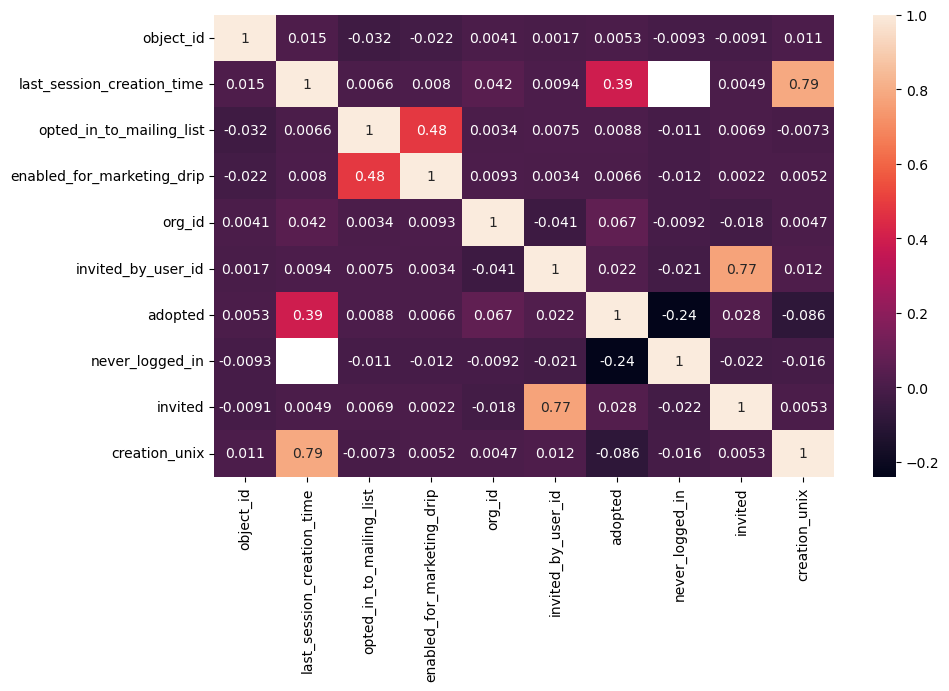

In [53]:
corr = dfUser.corr(numeric_only=True)
# Plot heatmap 
plt.figure(figsize=(10, 6)) 
sns.heatmap(corr, annot=True) 
plt.show()

Now we look at categorical features

<Axes: xlabel='creation_source', ylabel='adopted'>

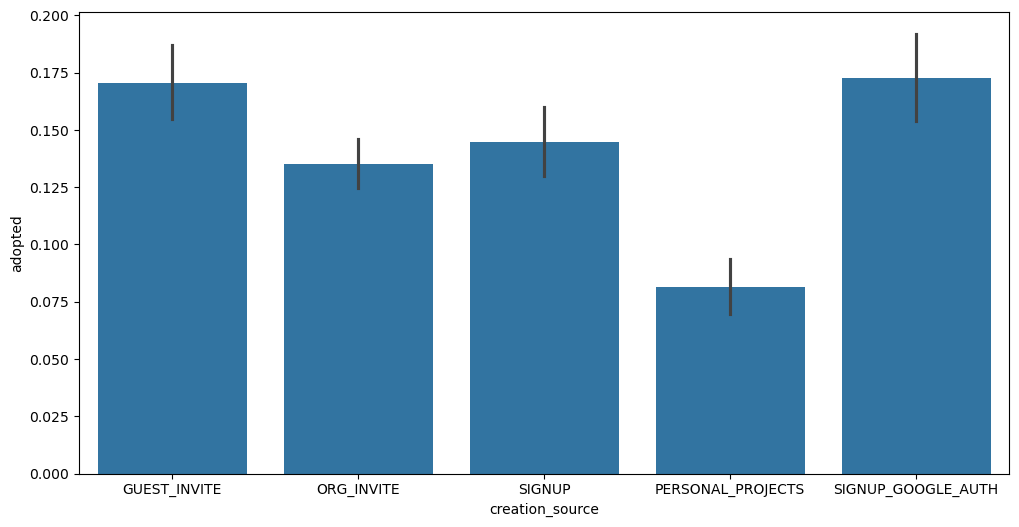

In [34]:
#creation source
plt.figure(figsize=(12, 6)) 
sns.barplot( data=dfUser, x="creation_source", y="adopted" )

In [37]:
#calculate the percentage of adopted based on creation source

yn_creation = dfUser.groupby('creation_source')['adopted'].value_counts().unstack().reset_index()
yn_creation['percent_Y'] = (yn_creation[1] / (yn_creation[1] + yn_creation[0])) * 100
yn_creation.sort_values('percent_Y', ascending = False)

adopted,creation_source,0,1,percent_Y,ratio_Y_to_N
4,SIGNUP_GOOGLE_AUTH,1146,239,17.256318,0.208551
0,GUEST_INVITE,1794,369,17.059639,0.205686
3,SIGNUP,1785,302,14.470532,0.169188
1,ORG_INVITE,3680,574,13.493183,0.155978
2,PERSONAL_PROJECTS,1939,172,8.147797,0.088706


<Axes: xlabel='invited', ylabel='adopted'>

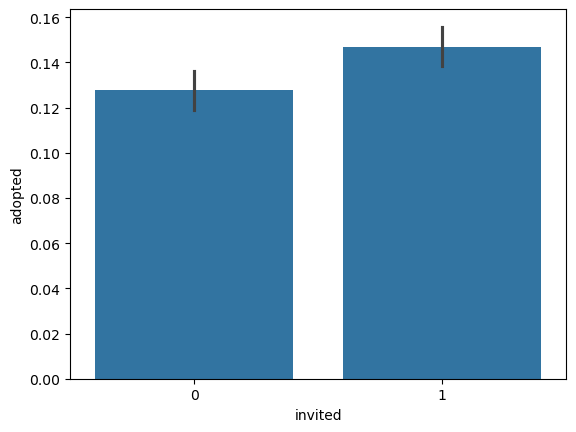

In [81]:
#invited
sns.barplot( data=dfUser, x="invited", y="adopted" )

In [41]:
#calculate the percentage of adopted based on creation source
yn_invited = dfUser.groupby('invited')['adopted'].value_counts().unstack().reset_index()
yn_invited['percent_Y'] = (yn_invited[1] / (yn_invited[1] + yn_invited[0])) * 100
yn_invited.sort_values('percent_Y', ascending = False)

adopted,invited,0,1,percent_Y
1,1,5474,943,14.695341
0,0,4870,713,12.770912


<Axes: xlabel='opted_in_to_mailing_list', ylabel='adopted'>

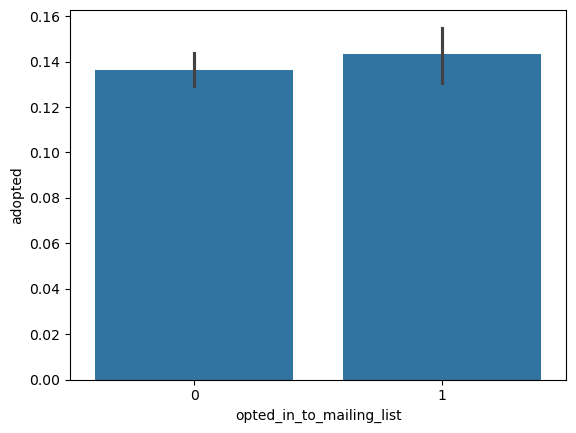

In [80]:
#mailing list
sns.barplot( data=dfUser, x="opted_in_to_mailing_list", y="adopted" )

<Axes: xlabel='enabled_for_marketing_drip', ylabel='adopted'>

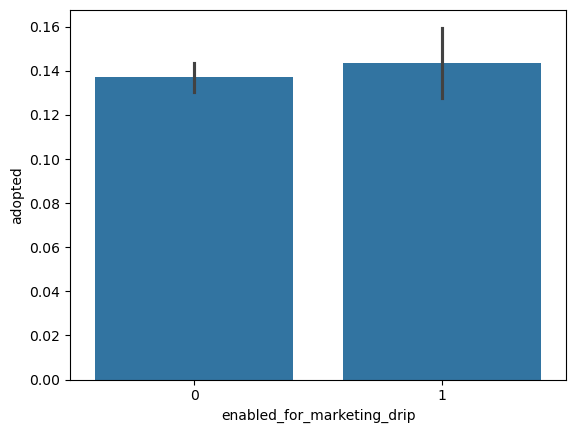

In [82]:
#marketing
sns.barplot( data=dfUser, x="enabled_for_marketing_drip", y="adopted" )

<Axes: xlabel='org_id', ylabel='adopted'>

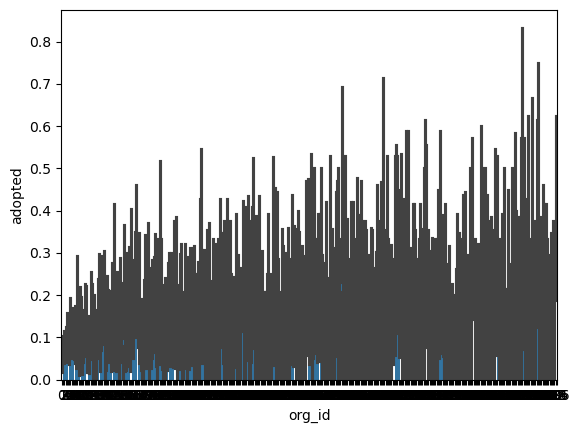

In [83]:
#org_id
sns.barplot( data=dfUser, x="org_id", y="adopted" )

In [54]:
#too many org ids, see how many there are
dfUser['org_id'].nunique()

417

In [84]:
#calculate the percentage and ratio of adopted based on org id

yn_org = dfUser.groupby('org_id')['adopted'].value_counts().unstack().reset_index()
yn_org['percent_Y'] = (yn_org[1] / (yn_org[1] + yn_org[0])) * 100
yn_org["total_users"] = yn_org[0] + yn_org[1]
yn_org = yn_org.sort_values('percent_Y', ascending = False)


In [85]:
yn_org.head(10)

adopted,org_id,0,1,percent_Y,total_users
387,387,5.0,7.0,58.333333,12.0
235,235,7.0,6.0,46.153846,13.0
270,270,8.0,6.0,42.857143,14.0
399,399,8.0,5.0,38.461538,13.0
415,415,10.0,6.0,37.500000,16.0
392,392,10.0,6.0,37.500000,16.0
400,400,5.0,3.0,37.500000,8.0
117,117,14.0,8.0,36.363636,22.0
345,345,9.0,5.0,35.714286,14.0
318,318,11.0,6.0,35.294118,17.0


In [57]:
yn_org.describe()

adopted,org_id,0,1,percent_Y,total_users
count,417.000000,417.000000,401.000000,401.000000,401.000000
mean,208.000000,24.805755,4.129676,16.108374,29.341646
std,120.521782,25.768630,2.608283,7.877381,27.936812
min,0.000000,2.000000,1.000000,2.631579,7.000000
25%,104.000000,14.000000,2.000000,10.526316,17.000000
50%,208.000000,18.000000,3.000000,14.814815,23.000000
75%,312.000000,25.000000,5.000000,20.000000,30.000000
max,416.000000,307.000000,17.000000,58.333333,319.000000


<Axes: >

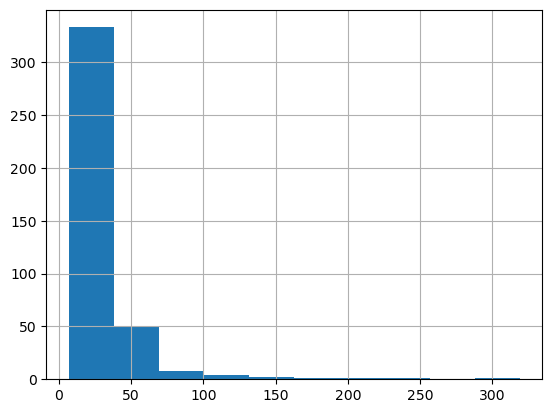

In [60]:
yn_org['total_users'].hist()

In [66]:
bins = [0, 15, 25, 40, yn_org.total_users.max()]
labels = ["very_small", "small", "medium", "large"]

yn_org["size_group"] = pd.cut(yn_org["total_users"], bins=bins, labels=labels)


In [74]:
yn_org.groupby("size_group",observed=True)["percent_Y"].mean()

size_group
very_small    19.708582
small         16.534402
medium        15.635916
large         11.243413
Name: percent_Y, dtype: float64

<Axes: xlabel='size_group', ylabel='percent_Y'>

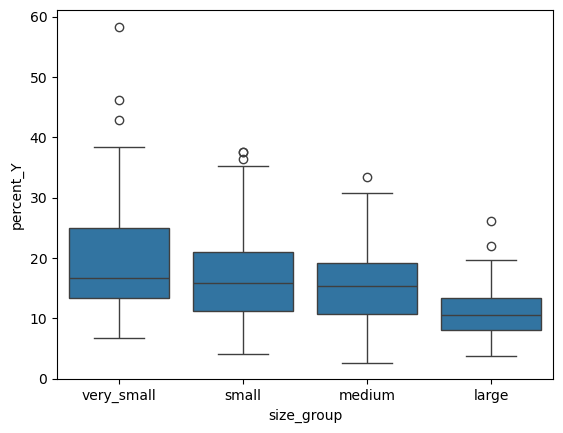

In [75]:
sns.boxplot(data=yn_org, x="size_group", y="percent_Y")


<Axes: xlabel='size_group', ylabel='percent_Y'>

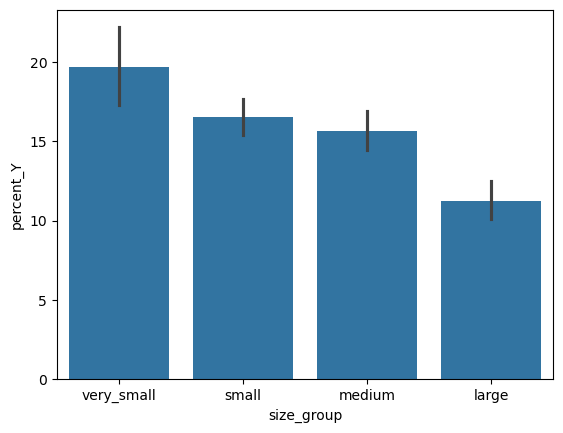

In [76]:
sns.barplot(data=yn_org, x="size_group", y="percent_Y")
